# Grow Gardens located around the Neighborhoods of Pittsburgh

The dataset I chose to work with is Grow Pittsburgh Food Gardens, which is a part of the non-profit Grow Pittsburgh. Grow Pittsburgh hopes to facilitate a greater level of accessibility in gardening throughout homes, schools, communities, and urban farms. I chose to use this dataset to evaluate the best neighborhood because it uniquely shows a hidden aspect of neighborhoods that not only brings communities together, but also provides a sustainable food source and hobby to its residents. 

---

### The Sub-metric 
**Self-Sufficiency**
We chose to measure our neighborhoods' "bestness" by their sustainability across mulitple different statistics. The grow gardens focus on a neighborhood's at least partial ability to be self-sufficient by creating their own produce. This makes a community less reliant on larger grocery stores and can allow for neighborhoods to have greater access to local, healthy, affordable, and culturally appropriate food as best stated by Grow Pittsburgh in their short biographical description.

In [1]:
import pandas as pd
import numpy as np
import fpsnippets

In [2]:
gardens = pd.read_csv("https://data.wprdc.org/dataset/0d8c9708-3f01-48c4-adff-04d29825c9a2/resource/dbdfcb3e-8fa5-4468-9b05-f69562798f7a/download/grow-pgh-food-gardens.csv")
gardens.head(80)

,urban_grower,grower_id,category,url,street_address,city,state,zip_code,country,latitude,longitude
0,Angora Gardens,584,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,3 Muse Lane,White Oak,Pennsylvania,15131.0,US,40.404686,-79.862095
1,Everybody's Garden,586,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,301 West Elizabeth Street,Pittsburgh,Pennsylvania,15207.0,US,40.406546,-79.945442
2,EvGard Extension,587,other,https://www.growpittsburgh.org/directory/garde...,NaN,Pittsburgh,Pennsylvania,15201.0,US,40.406377,-79.945559
3,Glen Hazel Communiuty Garden,588,other,https://www.growpittsburgh.org/directory/garde...,Johnston Avenue at Roselle Drive,Pittsburgh,Pennsylvania,15207.0,US,40.406040,-79.931253
4,Grow Pittsburgh,589,grow-pittsburgh-site,https://www.growpittsburgh.org/directory/garde...,6587 Hamilton Avenue #2W,Pittsburgh,Pennsylvania,15206.0,US,40.458481,-79.911381
...,...,...,...,...,...,...,...,...,...,...,...
75,Penn Hills Community Garden,734,allegheny-grows-site|sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,1162 Jefferson Road,Penn Hills,Pennsylvania,15235.0,US,40.447638,-79.798817
76,Stanton Heights Allegheny Cemetery Community G...,735,sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,Stanton Avenue,Pittsburgh,Pennsylvania,15201.0,US,40.473711,-79.961237
77,The Harry Orlando Memorial Community Garden,736,community-garden,https://www.growpittsburgh.org/directory/garde...,2205 5th Avenue,Pittsburgh,Pennsylvania,15219.0,US,40.438247,-79.973943
78,The Octopus Garden,738,community-garden,https://www.growpittsburgh.org/directory/garde...,133 S. Aiken Avenue,Pittsburgh,Pennsylvania,15206.0,US,40.463591,-79.936771


In [3]:
gardens_adj = pd.DataFrame(gardens)

neighborhoods_list = []

for index, row in gardens.iterrows():
    lat = row['latitude']
    long = row['longitude']
    neighborhoods_list.append(fpsnippets.geo_to_neighborhood(lat, long))

list_to_series = pd.Series(neighborhoods_list, name = 'neighborhoods')

gardens_adj['neighborhoods'] = list_to_series

gardens_adj.head(80)

,urban_grower,grower_id,category,url,street_address,city,state,zip_code,country,latitude,longitude,neighborhoods
0,Angora Gardens,584,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,3 Muse Lane,White Oak,Pennsylvania,15131.0,US,40.404686,-79.862095,None
1,Everybody's Garden,586,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,301 West Elizabeth Street,Pittsburgh,Pennsylvania,15207.0,US,40.406546,-79.945442,Hazelwood
2,EvGard Extension,587,other,https://www.growpittsburgh.org/directory/garde...,NaN,Pittsburgh,Pennsylvania,15201.0,US,40.406377,-79.945559,Hazelwood
3,Glen Hazel Communiuty Garden,588,other,https://www.growpittsburgh.org/directory/garde...,Johnston Avenue at Roselle Drive,Pittsburgh,Pennsylvania,15207.0,US,40.406040,-79.931253,Glen Hazel
4,Grow Pittsburgh,589,grow-pittsburgh-site,https://www.growpittsburgh.org/directory/garde...,6587 Hamilton Avenue #2W,Pittsburgh,Pennsylvania,15206.0,US,40.458481,-79.911381,Larimer
...,...,...,...,...,...,...,...,...,...,...,...,...
75,Penn Hills Community Garden,734,allegheny-grows-site|sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,1162 Jefferson Road,Penn Hills,Pennsylvania,15235.0,US,40.447638,-79.798817,None
76,Stanton Heights Allegheny Cemetery Community G...,735,sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,Stanton Avenue,Pittsburgh,Pennsylvania,15201.0,US,40.473711,-79.961237,Central Lawrenceville
77,The Harry Orlando Memorial Community Garden,736,community-garden,https://www.growpittsburgh.org/directory/garde...,2205 5th Avenue,Pittsburgh,Pennsylvania,15219.0,US,40.438247,-79.973943,West Oakland
78,The Octopus Garden,738,community-garden,https://www.growpittsburgh.org/directory/garde...,133 S. Aiken Avenue,Pittsburgh,Pennsylvania,15206.0,US,40.463591,-79.936771,Bloomfield


---
### The Best Neighborhood
Determining the best Neighborhood in Pittsburgh according to the number of grow gardens

In [4]:
gardens_by_neighborhood = gardens_adj.groupby("neighborhoods").count().loc[:,"urban_grower"].sort_values(ascending=False)
gardens_by_neighborhood[:10]

neighborhoods
Garfield                 4
East Liberty             4
Point Breeze             4
West Oakland             3
Larimer                  3
Hazelwood                3
South Oakland            3
Central Lawrenceville    3
Middle Hill              2
Bloomfield               2
Name: urban_grower, dtype: int64

<Axes: title={'center': 'Number of Grow Gardens by Neighborhood in Pittsburgh'}, xlabel='neighborhoods'>

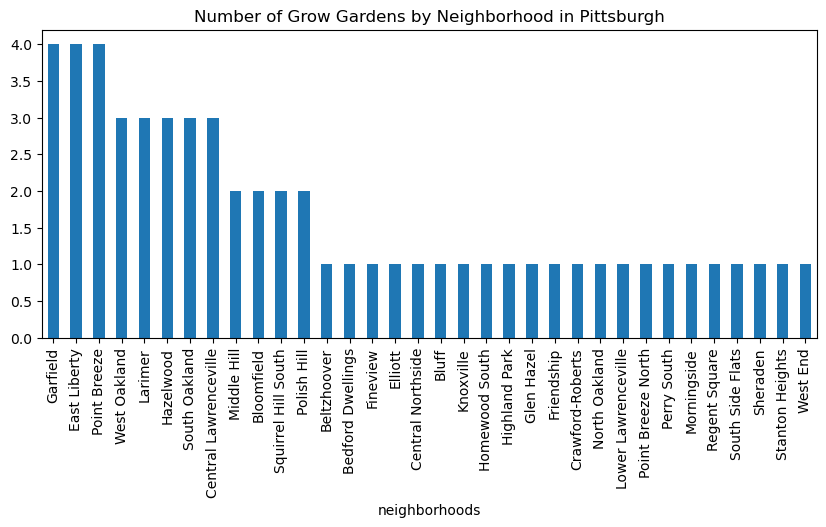

In [5]:
gardens_by_neighborhood.plot.bar(title = "Number of Grow Gardens by Neighborhood in Pittsburgh", figsize = (10,4))

According to this graph which shows the number of grow gardens by neighborhood in Pittsburgh, the top 3 neighborhoods are Garfield, East Liberty, and Point Breeze, which all tied with 4 grow gardens in each of their neighborhoods. However, it is also important to note the 5 neighborhoods, West Oakland, Larimer, Hazelwood, South Oakland, and Central Lawrenceville, all had 3 grow gardens each. Another significant set is Middle Hill, Bloomfield, Squirrel Hill South, and Polish Hill, which each have 2 grow gardens in each of their neighborhoods. These top 12 neighborhoods have a significant number of grow gardens within each of them compared to all other neighborhoods in oakland that have 1 or less.

---
## Conclusion
By only looking at this dataset, it becomes aparent that the neighborhoods of Garfield, East Liberty, and Point Breeze take the title of most self-sufficient according to their number of grow gardens. As someone who is new to Pittsburgh, my understanding of the city's neighborhoods is minimal so naturally Central Oakland would have to be my favorite, but there is not a single grow garden within the neighborhood. I believe that this can lead to two conclusions, firstly being that those previously listed neighborhoods are the "best", but also that these other neighborhoods, especially Central Oakland, should use this at a call to create grow gardens in their own neighborhoods to better their communities.